<a href="https://colab.research.google.com/github/yashb98/90Days_Machine_learinng/blob/main/CNNvsResnet50Finetuned_Comparison(Project8%20day21).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load and Prepare Dataset

In [8]:


import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
from zipfile import ZipFile




### Unzip your dataset (make sure seg_train.zip & seg_test.zip are uploaded in the notebook workspace)

 List files in the current directory to confirm upload

In [9]:
print("Current directory files:")
!ls

# Unzip train and test datasets
for zip_file in ["seg_train.zip", "seg_test.zip"]:
    if os.path.exists(zip_file):
        print(f"Extracting {zip_file} ...")
        with ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall()   # Extracts into /content/seg_train and /content/seg_test
    else:
        print(f"{zip_file} not found. Please upload it to your Colab environment.")



Current directory files:
data  sample_data  seg_test  seg_test.zip  seg_train  seg_train.zip
Extracting seg_train.zip ...
Extracting seg_test.zip ...



### Define dataset directories

In [10]:

train_dir = '/content/seg_train'
test_dir = '/content/seg_test'



###Define transforms

 These help resize images and add basic augmentations for better model generalization

In [11]:

train_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])



###Load datasets

In [12]:

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
test_data = datasets.ImageFolder(test_dir, transform=test_transforms)



### Create DataLoaders

In [13]:

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)



### Print dataset details

In [14]:

print("Classes:", train_data.classes)
print("Number of training images:", len(train_data))
print("Number of testing images:", len(test_data))



Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of training images: 14034
Number of testing images: 3000


###  Visualise a few training images

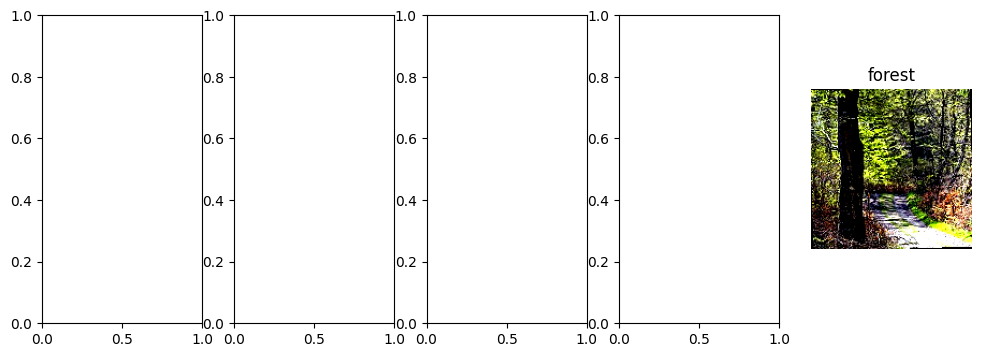

In [15]:

def imshow(img, title):
    img = img / 2 + 0.5  # unnormalize for display
    plt.imshow(img.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')

# Get a batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Display 5 sample images
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i in range(5):
    imshow(images[i], title=train_data.classes[labels[i]])
plt.show()

## Build a CNN from Scratch

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Running on:", device)

import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Adaptive pooling ensures fixed output regardless of input image size
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 6)  # 6 classes (buildings, forest, glacier, mountain, sea, street)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.adaptive_pool(x)
        x = self.fc_layers(x)
        return x


Running on: cuda


In [22]:
model_scratch = SimpleCNN().to(device)

for imgs, labels in train_loader:
    imgs = imgs.to(device)
    out = model_scratch.conv_layers(imgs)
    print("After conv:", out.shape)
    out = model_scratch.adaptive_pool(out)
    print("After adaptive pool:", out.shape)
    out = torch.flatten(out, 1)
    print("After flatten:", out.shape)
    break

After conv: torch.Size([32, 64, 37, 37])
After adaptive pool: torch.Size([32, 64, 4, 4])
After flatten: torch.Size([32, 1024])


In [23]:
model_scratch = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=0.001)

## Train the CNN from Scratch

In [26]:
def train_model(model, loader, epochs=5):
    model.train()
    for epoch in range(epochs):
        total_loss, correct = 0, 0
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
        acc = correct / len(loader.dataset) * 100
        print(f"Epoch [{epoch+1}/{epochs}] → Loss: {total_loss/len(loader):.4f}, Accuracy: {acc:.2f}%")



In [28]:
train_model(model_scratch, train_loader, epochs=10)

Epoch [1/10] → Loss: 0.4300, Accuracy: 84.35%
Epoch [2/10] → Loss: 0.4023, Accuracy: 85.39%
Epoch [3/10] → Loss: 0.3907, Accuracy: 85.59%
Epoch [4/10] → Loss: 0.3680, Accuracy: 86.49%
Epoch [5/10] → Loss: 0.3470, Accuracy: 87.00%
Epoch [6/10] → Loss: 0.3280, Accuracy: 88.11%
Epoch [7/10] → Loss: 0.3173, Accuracy: 88.31%
Epoch [8/10] → Loss: 0.3087, Accuracy: 88.61%
Epoch [9/10] → Loss: 0.2954, Accuracy: 89.38%
Epoch [10/10] → Loss: 0.2810, Accuracy: 89.65%


 ## Evaluate on Test Data

In [32]:
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            correct += (outputs.argmax(1) == labels).sum().item()
    acc = correct / len(loader.dataset) * 100
    return acc

scratch_acc = evaluate_model(model_scratch, test_loader)
print(f" CNN from Scratch Test Accuracy: {scratch_acc:.2f}%")

 CNN from Scratch Test Accuracy: 86.73%


## Compare with Fine-Tuned ResNet50 (from Day 20)

💻 Using device: cuda
 Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Training samples: 14034, Validation samples: 3000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]



Epoch 1/10
----------------------------------------


...

Val | Loss: 0.1693 | Accuracy: 0.9440

Epoch 10/10
----------------------------------------


Train Epoch 10: 100%|██████████| 439/439 [02:21<00:00,  3.11it/s]


Train | Loss: 0.0586 | Accuracy: 0.9812


Val Epoch 10: 100%|██████████| 94/94 [00:15<00:00,  6.07it/s]


Val | Loss: 0.1678 | Accuracy: 0.9443

 Training complete in 25m 56s
 Best Validation Accuracy: 0.9443
 Model saved as resnet50_intel_finetuned.pth


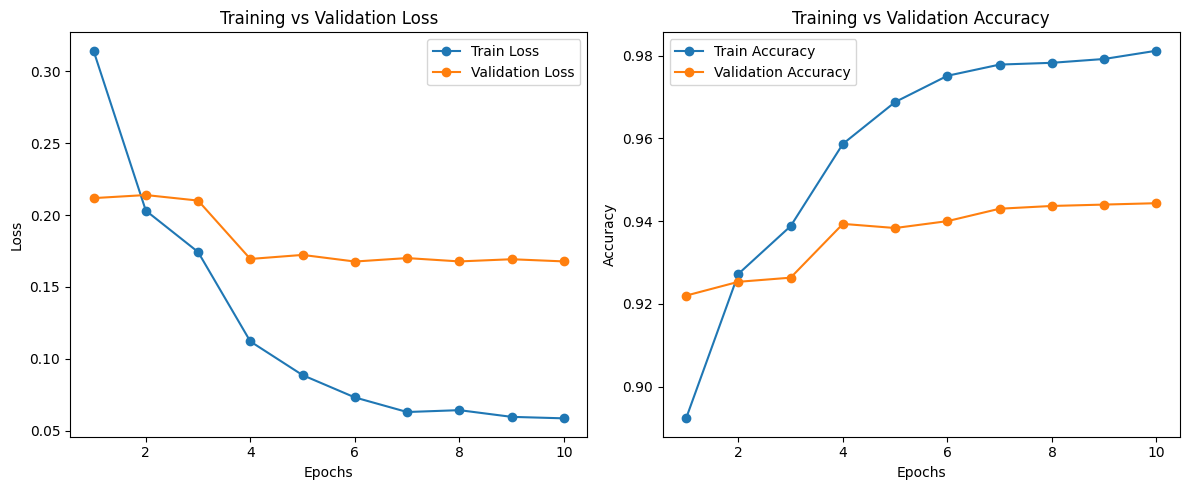

In [34]:
"""
Day 20 — Fine-Tuning ResNet50 on Intel Image Classification Dataset
Author: Yash Bishnoi
Goal: Fine-tune deeper layers of a pre-trained ResNet50 to achieve >94% accuracy
"""

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import numpy as np
import time
import copy
from tqdm import tqdm

# ---------------------------
# Device setup
# ---------------------------
device = torch.device("mps" if torch.backends.mps.is_available(
) else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------
# Data Preparation
# ---------------------------

train_dir = "/content/seg_train"
val_dir = "/content/seg_test"

# Data augmentation and normalization
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32,
                        shuffle=False, num_workers=0)

class_names = train_dataset.classes
print(f" Classes: {class_names}")
print(
    f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

# ---------------------------
#  Model Setup: Fine-Tuning ResNet50
# ---------------------------
model = models.resnet50(pretrained=True)

# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze deeper layers (layer3, layer4)
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True

# Replace classifier
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model = model.to(device)

# ---------------------------
#  Loss, Optimizer, Scheduler
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# ---------------------------
#  Training Function with Early Stopping
# ---------------------------


def train_model(model, criterion, optimizer, scheduler, num_epochs=10, patience=3):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    patience_counter = 0

    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in tqdm(dataloader, desc=f"{phase.capitalize()} Epoch {epoch+1}"):
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.float() / len(dataloader.dataset)

            if phase == 'train':
                scheduler.step()
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())

            print(
                f"{phase.capitalize()} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

            # deep copy the model if it improves
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(" Early stopping triggered.")
            break

    time_elapsed = time.time() - since
    print(
        f"\n Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f" Best Validation Accuracy: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    torch.save(model.state_dict(), "resnet50_intel_finetuned.pth")
    print(" Model saved as resnet50_intel_finetuned.pth")

    return model, (train_loss_history, val_loss_history, train_acc_history, val_acc_history)


# ---------------------------
# Train the Model
# ---------------------------
model, history = train_model(
    model, criterion, optimizer, scheduler, num_epochs=10)

# ---------------------------
# Visualization
# ---------------------------
train_loss, val_loss, train_acc, val_acc = history

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'o-', label='Train Loss')
plt.plot(epochs, val_loss, 'o-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'o-', label='Train Accuracy')
plt.plot(epochs, val_acc, 'o-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [35]:
from torchvision import models

resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Linear(resnet50.fc.in_features, 6)
resnet50.load_state_dict(torch.load('/content/resnet50_intel_finetuned.pth', map_location=device))
resnet50 = resnet50.to(device)

finetune_acc = evaluate_model(resnet50, test_loader)
print(f" Fine-Tuned ResNet50 Test Accuracy: {finetune_acc:.2f}%")

 Fine-Tuned ResNet50 Test Accuracy: 92.57%


## Compare and Visualize Results

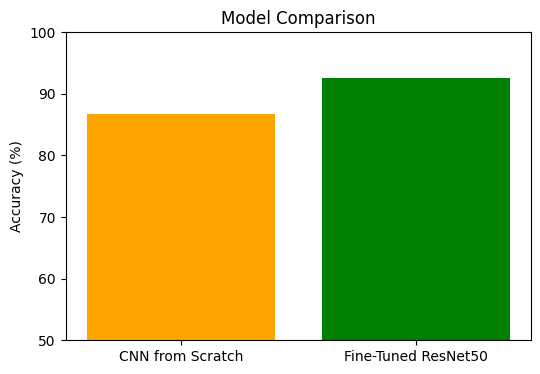

In [36]:
import matplotlib.pyplot as plt

models_name = ['CNN from Scratch', 'Fine-Tuned ResNet50']
accuracy = [scratch_acc, finetune_acc]

plt.figure(figsize=(6,4))
plt.bar(models_name, accuracy, color=['orange', 'green'])
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
plt.ylim(50, 100)
plt.show()

## Analysis

This notebook demonstrates training a simple CNN from scratch and fine-tuning a pre-trained ResNet50 model for image classification on the Intel Image Classification dataset.

**Code Analysis:**

1.  **Data Loading and Preparation:**
    *   The notebook starts by importing necessary libraries like `torch`, `torchvision`, `matplotlib`, and `os`.
    *   It then unzips the training and testing datasets (`seg_train.zip` and `seg_test.zip`).
    *   Directories for the extracted datasets are defined (`train_dir`, `test_dir`).
    *   Data transformations are defined using `torchvision.transforms`. These include resizing, random flips and rotations for training data augmentation, converting to tensors, and normalization using ImageNet mean and standard deviation. This is a standard practice for image datasets.
    *   `ImageFolder` is used to load the datasets, automatically inferring class labels from the directory structure.
    *   `DataLoader` is used to create iterable data loaders for training and testing, enabling batch processing and shuffling of training data.
    *   Dataset details (classes and number of images) are printed, confirming the data is loaded correctly.
    *   A function `imshow` is defined to visualize sample images, which is helpful for verifying the data loading and transformations. The warning about clipping data during display is expected because the images are normalized to a range outside [0, 1].

2.  **Building a CNN from Scratch:**
    *   A simple CNN model (`SimpleCNN`) is defined using `torch.nn.Module`.
    *   It consists of two convolutional layers with ReLU activation and max pooling, followed by an adaptive average pooling layer to handle varying input sizes and flatten the output for the fully connected layers.
    *   The fully connected layers classify the images into 6 classes.
    *   The model is moved to the appropriate device (GPU if available, otherwise CPU).
    *   A small test is performed to check the output shapes after each layer, ensuring the dimensions are as expected before the fully connected layers.

3.  **Training the CNN from Scratch:**
    *   The `SimpleCNN` model, `CrossEntropyLoss` criterion, and `Adam` optimizer are initialized.
    *   A `train_model` function is defined to handle the training loop. It iterates through epochs, batches, calculates loss, performs backpropagation, and updates model weights.
    *   Training loss and accuracy are printed for each epoch.
    *   The model is trained for 10 epochs.

4.  **Evaluating on Test Data:**
    *   An `evaluate_model` function is defined to calculate the accuracy on the test set. It sets the model to evaluation mode (`model.eval()`), disables gradient calculation (`torch.no_grad()`), and iterates through the test loader, calculating the number of correct predictions.
    *   The test accuracy for the CNN from scratch is calculated and printed.

5.  **Comparing with Fine-Tuned ResNet50:**
    *   This section loads code from "Day 20" which is a script for fine-tuning ResNet50.
    *   It sets up the device, defines data transformations (including resizing to 224x224 for ResNet50), loads datasets and data loaders similar to the scratch CNN setup.
    *   It loads a pre-trained ResNet50 model (`models.resnet50(pretrained=True)` - although the warning indicates `weights` should be used instead of `pretrained`).
    *   All layers of ResNet50 are initially frozen, and then deeper layers (`layer3`, `layer4`) and the final fully connected layer (`fc`) are unfrozen to allow fine-tuning.
    *   The final fully connected layer is replaced to match the number of classes in the dataset (6).
    *   Loss function (`CrossEntropyLoss`), optimizer (`Adam`), and a learning rate scheduler (`StepLR`) are defined.
    *   A `train_model` function (different from the one used for the scratch CNN) is defined for the fine-tuning process. This function includes epoch and phase (train/val) loops, progress bars (`tqdm`), and early stopping based on validation accuracy.
    *   The ResNet50 model is trained for up to 10 epochs with early stopping.
    *   Training and validation loss and accuracy are plotted over epochs.
    *   The best model weights based on validation accuracy are saved.
    *   The saved ResNet50 model weights are loaded, and the model is evaluated on the test set. The test accuracy for the fine-tuned ResNet50 is printed.

6.  **Compare and Visualize Results:**
    *   The test accuracies of the CNN from scratch and the fine-tuned ResNet50 are stored in lists.
    *   A bar plot is generated using `matplotlib` to visually compare the test accuracies of the two models.

**Results and Conclusion:**

The CNN from scratch achieved a test accuracy of **86.73%**.
The Fine-Tuned ResNet50 achieved a test accuracy of **92.57%**.

The fine-tuned ResNet50 model significantly outperformed the CNN trained from scratch. This is expected because ResNet50 is a much deeper and more complex architecture that has been pre-trained on a massive dataset (ImageNet). Fine-tuning allows the model to leverage the features learned from this large dataset and adapt them to the new task, resulting in better performance with less training data compared to training a deep network from scratch.

**Summary:**

This notebook successfully demonstrates two approaches to image classification: training a simple CNN from scratch and fine-tuning a pre-trained ResNet50. The results clearly show the advantage of using transfer learning with a powerful pre-trained model like ResNet50 for image classification tasks, achieving a higher accuracy on the test set compared to a simple CNN trained from scratch on the same dataset. The fine-tuned ResNet50 model is a better choice for this task due to its superior performance.